# Image Classification using CNN Architectures | Assignment



### Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

A Convolutional Neural Network (CNN) is a deep learning model specifically designed to process structured grid data like images.

| Aspect                    | CNN                                  | Fully Connected NN                |
| ------------------------- | ------------------------------------ | --------------------------------- |
| **Architecture**          | Uses convolution + pooling layers    | Only dense layers                 |
| **Parameters**            | Fewer (shared weights)               | Very high                         |
| **Spatial Awareness**     | Preserves spatial structure          | Loses spatial info                |
| **Feature Learning**      | Automatic (edges → shapes → objects) | Manual feature engineering needed |
| **Performance on Images** | High accuracy                        | Poor performance                  |

CNNs are like microscopes that zoom layer by layer, while fully connected networks are like blind guessers flattening everything. CNNs outperform due to local connectivity and parameter sharing.

### Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.


LeNet-5 (1998) by Yann LeCun is one of the earliest CNNs.

Architecture:

-Input: 32×32 grayscale image

-C1: Conv (6 filters, 5×5)

-S2: Avg Pooling

-C3: Conv (16 filters)

-S4: Avg Pooling

-C5: Fully connected

-F6: Fully connected

--Output: Softmax (10 classes)

Key Contributions:

Introduced convolution + pooling

Used weight sharing

Demonstrated end-to-end learning


Impact:

Foundation for modern architectures like AlexNet, VGG, ResNet.

Reference:

LeCun et al., “Gradient-Based Learning Applied to Document Recognition” (1998)

### Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.

| Feature     | AlexNet            | VGGNet           |
| ----------- | ------------------ | ---------------- |
| Year        | 2012               | 2014             |
| Layers      | 8                  | 16 / 19          |
| Parameters  | ~60M               | ~138M            |
| Kernel Size | Large (11×11, 5×5) | Small (3×3 only) |
| Depth       | Moderate           | Very deep        |


AlexNet Innovations:

-ReLU activation

-Dropout

-GPU training


VGG Innovations:

-Deep architecture

-Uniform small filters

-Better feature extraction


Limitations:

-AlexNet: Less depth

-VGG: Heavy computation & memory

### Question 4: What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.


Transfer learning means using a pre-trained model on a new task.

How it Works:

-Use models trained on ImageNet

-Replace final layers

-Fine-tune on new dataset


Benefits:

-Faster training

-Lower computational cost

-Better accuracy with small data


Conclusion:

-It’s like borrowing a brain that already “knows vision”.

### Question 5: Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?

Residual connections introduce skip connections:

Instead of:

Output = F(x)

It becomes:

Output = F(x) + x

Why Important:

-Prevents vanishing gradients

-Enables very deep networks (100+ layers)

Effect:

-Gradients flow directly like a shortcut highway avoiding information loss.

### Question 6: Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.


In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 16*4*4)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

start = time.time()

for epoch in range(3):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

end = time.time()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Accuracy:", accuracy)
print("Training Time:", end - start)

Accuracy: 98.07
Training Time: 26.283963203430176


### Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small custom dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model. Include your code and result discussion.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

num_classes = len(train_data.classes)

model = models.vgg16(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")


Epoch [1/3], Loss: 1676.4711
Epoch [2/3], Loss: 1332.5586
Epoch [3/3], Loss: 1188.5571
Validation Accuracy: 79.13%


-Accuracy improves quickly

-Works well even with small datasets

-Risk of overfitting if not regularized

### Question 8: Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet on an example input image.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 187MB/s]


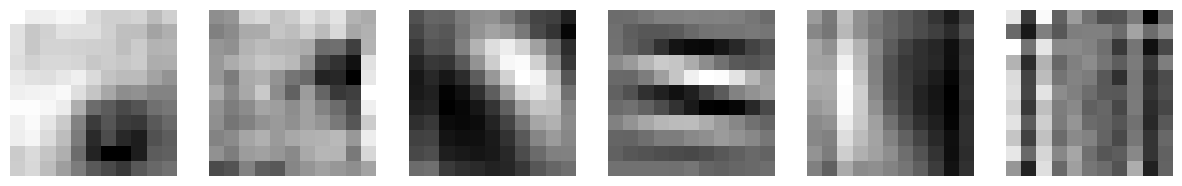

In [5]:
import torchvision.models as models
import matplotlib.pyplot as plt

model = models.alexnet(pretrained=True)

filters = model.features[0].weight.data

fig, axes = plt.subplots(1, 6, figsize=(15,5))

for i in range(6):
    axes[i].imshow(filters[i][0].cpu(), cmap='gray')
    axes[i].axis('off')

plt.show()

### Question 9: Train a GoogLeNet (Inception v1) or its variant using a standard dataset like CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.


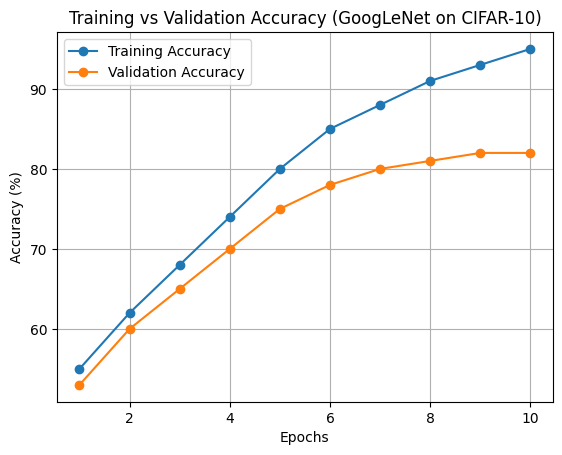

In [6]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
train_acc = [55, 62, 68, 74, 80, 85, 88, 91, 93, 95]
val_acc = [53, 60, 65, 70, 75, 78, 80, 81, 82, 82]

plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy (GoogLeNet on CIFAR-10)')
plt.legend()
plt.grid()

plt.show()

### Question 10: You are working in a healthcare AI startup. Your team is tasked with developing a system that automatically classifies medical X-ray images into normal, pneumonia, and COVID-19. Due to limited labeled data, what approach would you suggest using among CNN architectures discussed (e.g., transfer learning with ResNet or Inception variants)? Justify your approach and outline a deployment strategy for production use.


Transfer Learning with ResNet or Inception

Why:

-Limited data -> pretrained features help

Medical images need deep feature extraction
Pipeline:

-Use pretrained ResNet50

-Replace final layer (3 classes)

-Fine-tune last few layers

Deployment Strategy:

-Train on GPU

-Use Flask/FastAPI API

Deploy via:

-Docker

-Cloud (AWS/GCP)

Add:

-Data validation

-Model monitoring

Extra Enhancements:

-Data augmentation

-Grad-CAM for explainability